<a href="https://colab.research.google.com/github/shivani-rabari/Customer-Churn-Prediction/blob/main/churn_project_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Customer Churn Prediction System

## Import required libraries


In [2627]:
# import numpy
# This library help us to perform numerical operations on python data structures
import numpy as np

# import pandas
# This library help us to perform manipulation on python data structures
import pandas as pd

# import seaborn and matplotlib
# These libraries help us to perform visualizations on python data structures
import seaborn as sns
import matplotlib.pyplot as plt

In [2628]:
# Read the data
df_churn_dataset=pd.read_csv('churn_dataset.csv')

In [2629]:
# Read the first 5 observations of the data
df_churn_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2630]:
# Show the last 5 observations
df_churn_dataset.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Data Overview

In [2631]:
# Check the number of observations and attributes
df_churn_dataset.shape

(7043, 21)

In [2632]:
# Inference
# We have 21 attributes and 7043 observations

In [2633]:
# Check the columns (attributes) of the data
df_churn_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [2634]:
# Interpretation
# customerID = Unique identifier assigned to each customer.
# gender = Gender of the customer.
# SeniorCitizen = Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).
# Partner = Indicates whether the customer has a spouse or partner (Yes/No).
# Dependents = Indicates whether the customer has dependents (Yes/No).
# tenure = Number of months the customer has been associated with the company.
# PhoneService = Indicates whether the customer has a phone service subscription (Yes/No).
# MultipleLines = Indicates whether the customer has multiple phone lines (Yes/No/No phone service).
# InternetService = Type of internet service subscribed to by the customer (e.g., DSL, Fiber optic, None).
# OnlineSecurity = Indicates whether the customer has an online security service (Yes/No/No internet service).
# OnlineBackup = Indicates whether the customer has an online backup service (Yes/No/No internet service).
# DeviceProtection = Indicates whether the customer has a device protection plan (Yes/No/No internet service).
# TechSupport = Indicates whether the customer has technical support service (Yes/No/No internet service).
# StreamingTV = Indicates whether the customer subscribes to TV streaming service (Yes/No/No internet service).
# StreamingMovies = Indicates whether the customer subscribes to movie streaming service (Yes/No/No internet service).
# Contract = Type of contract the customer has (e.g., Month-to-month, One year, Two year).
# PaperlessBilling = Indicates whether the customer uses paperless billing (Yes/No).
# PaymentMethod = Method used by the customer to make payments.
# MonthlyCharges = Total amount charged to the customer per month.
# TotalCharges = Total amount charged to the customer over the entire tenure.
# Churn = Indicates whether the customer has discontinued the service (Yes = Churned, No = Retained).
# NOTE: Write column name and its description

In [2635]:
# Check the basic info about the data
df_churn_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2636]:
# Interpretation
# We have a small-sized dataset because the data size is approximately 1.1+ MB.
# The dataset contains 7,043 records (rows) and 21 columns (features).
# We have 3 numerical columns (2 integer and 1 float).
# We have 18 categorical columns.
# We don't have any missing records in the dataset, as all columns have 7,043 non-null values.
# The 'customerID' column is an identifier and can be excluded from model training.
# The 'TotalCharges' column is stored as an object data type and may require conversion to a numerical data type for analysis.

## Data Pre-Processing

### Data Cleaning

In [2637]:
# Renaming action
df_churn_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [2638]:
# Create the dictionary for new column assignment
dictionary1={
    'customerID' : 'Customer_ID',
    'gender' : 'Gender',
    'SeniorCitizen' : 'Senior_Citizen',
    'Partner' : 'Partner',
    'Dependents' : 'Dependents',
    'tenure' : 'Tenure',
    'PhoneService' : 'Phone_Service',
    'MultipleLines' : 'Multiple_Lines',
    'InternetService' : 'Internet_Service',
    'OnlineSecurity' : 'Online_Security',
    'OnlineBackup' : 'Online_Backup',
    'DeviceProtection' : 'Device_Protection',
    'TechSupport' : 'Tech_Support',
    'StreamingTV' : 'Streaming_TV',
    'StreamingMovies' : 'Streaming_Movies',
    'Contract' : 'Contract',
    'PaperlessBilling' : 'Paperless_Billing',
    'PaymentMethod' : 'Payment_Method',
    'MonthlyCharges' : 'Monthly_Charges',
    'TotalCharges' : 'Total_Charges',
    'Churn' : 'Churn'
}

In [2639]:
# Perform the renaming
df_churn_dataset = df_churn_dataset.rename(columns=dictionary1)

In [2640]:
# Authentic Check
df_churn_dataset.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Tenure', 'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

In [2641]:
# Observe the entities that requires type casting
df_churn_dataset.head()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2642]:
# Check the Datatypes of attributes
df_churn_dataset.dtypes

,0
Customer_ID,object
Gender,object
Senior_Citizen,int64
Partner,object
Dependents,object
Tenure,int64
Phone_Service,object
Multiple_Lines,object
Internet_Service,object
Online_Security,object


### EDA (Explorative Data Analysis)

#### Univariate Analysis

In [2643]:
# Segregate the data based on the data types
df_num = df_churn_dataset.select_dtypes(include='number')
df_cat = df_churn_dataset.select_dtypes(include='object')

In [2644]:
# Univariate analysis on  numerical data

In [2645]:
# So the numerical columns
df_num.columns

Index(['Senior_Citizen', 'Tenure', 'Monthly_Charges'], dtype='object')

In [2646]:
# Senior_Citizen

In [2647]:
# We need to convert Senior_Citizen data to categorical
df_churn_dataset.Senior_Citizen=df_churn_dataset.Senior_Citizen.astype('object')

In [2648]:
# Segregate the data based on the data types
df_cat = df_churn_dataset.select_dtypes(include='object')

In [2649]:
# Check the numerical columns
df_num.columns

Index(['Senior_Citizen', 'Tenure', 'Monthly_Charges'], dtype='object')

In [2650]:
# Tenure

In [2651]:
# Find minimun
df_num.Tenure.min()

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


0

In [2652]:
# Find maximum
df_num.Tenure.max()

72

In [2653]:
# Find average
df_num.Tenure.mean()

np.float64(32.37114865824223)

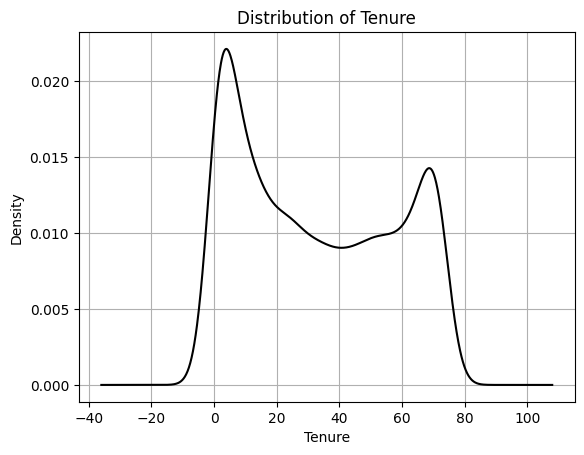

In [2654]:
# Plot the KDE Plot
df_num.Tenure.plot(kind='kde',color='black')
plt.grid()
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.show()

In [2655]:
# Inference
# Minimum Tenure is: 0
# Maximum Tenure is: 72
# Average Tenure is: 32.37114865824223
# We have multimodel data

In [2656]:
# Check the columns
df_num.columns

Index(['Senior_Citizen', 'Tenure', 'Monthly_Charges'], dtype='object')

In [2657]:
# Monthly_Charges

In [2658]:
# Find minimum
df_num.Monthly_Charges.min()

18.25

In [2659]:
# Find maximum
df_num.Monthly_Charges.max()

118.75

In [2660]:
# Find Average
df_num.Monthly_Charges.mean()

np.float64(64.76169246059918)

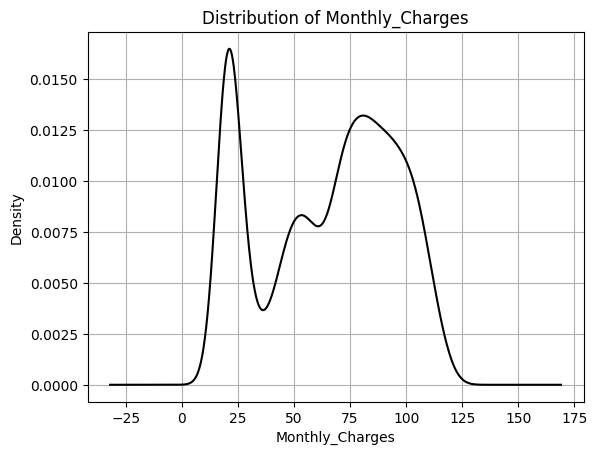

In [2661]:
# Plot the KDE Plot
df_num.Monthly_Charges.plot(kind='kde',color='black')
plt.grid()
plt.title('Distribution of Monthly_Charges')
plt.xlabel('Monthly_Charges')
plt.show()

In [2662]:
# Inference
# Minimum monthly charges is: 18.25
# Maximum monthly charges is: 118.75
# Average monthly charges is: 64.76169246059918

In [2663]:
# Univariate Analysis on Categorical Data
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2664]:
# Gender

In [2665]:
# Check the count of each category
df_cat.Gender.value_counts()

,count
Gender,
Male,3555
Female,3488


In [2666]:
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2667]:
# Senior_Citizen

In [2668]:
# Check the count of each category
df_cat.Senior_Citizen.value_counts()

,count
Senior_Citizen,
0,5901
1,1142


In [2669]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2670]:
# Partner

In [2671]:
# Check the count of each category
df_cat.Partner.value_counts()

,count
Partner,
No,3641
Yes,3402


In [2672]:
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2673]:
# Dependents

In [2674]:
# Check the count of each category
df_cat.Dependents.value_counts()

,count
Dependents,
No,4933
Yes,2110


In [2675]:
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2676]:
# Phone_Service

In [2677]:
# Check the count of each category
df_cat.Phone_Service.value_counts()

,count
Phone_Service,
Yes,6361
No,682


In [2678]:
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2679]:
# Multiple_Lines

In [2680]:
# Check the count of each category
df_cat.Multiple_Lines.value_counts()

,count
Multiple_Lines,
No,3390
Yes,2971
No phone service,682


In [2681]:
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2682]:
# Internet_Service

In [2683]:
# Check the count of each category
df_cat.Internet_Service.value_counts()

,count
Internet_Service,
Fiber optic,3096
DSL,2421
No,1526


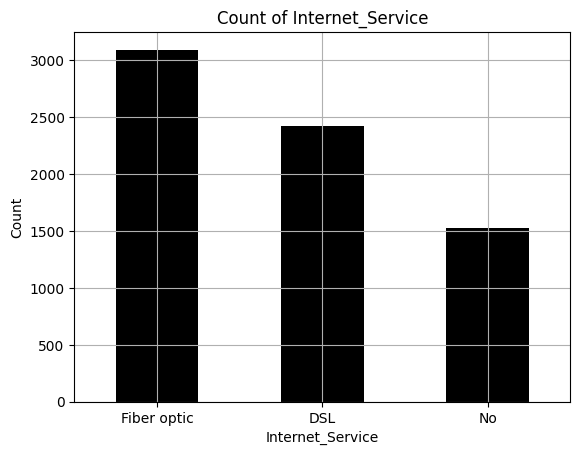

In [2684]:
# Plot the count
df_cat.Internet_Service.value_counts().plot(kind='bar', color='black')
plt.title('Count of Internet_Service')
plt.xlabel('Internet_Service')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid()
plt.show()

In [2685]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2686]:
# Online_Security

In [2687]:
# Check the count of each category
df_cat.Online_Security.value_counts()

,count
Online_Security,
No,3498
Yes,2019
No internet service,1526


In [2688]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2689]:
# Device_Protection

In [2690]:
# Check the count of each category
df_cat.Device_Protection.value_counts()

,count
Device_Protection,
No,3095
Yes,2422
No internet service,1526


In [2691]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2692]:
# Contract

In [2693]:
# Check the count of each category
df_cat.Contract.value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


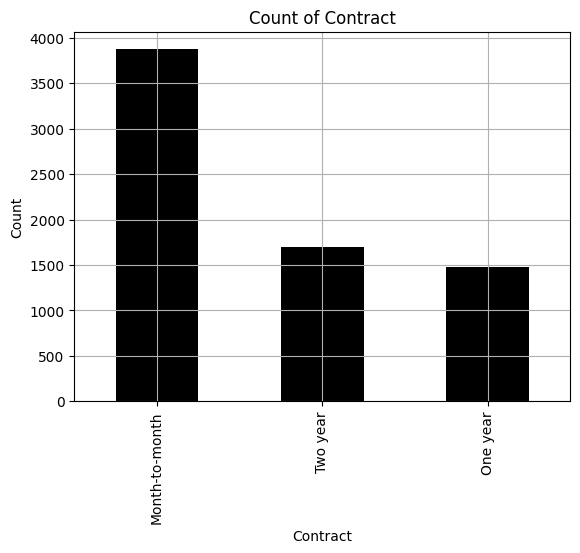

In [2694]:
# Plot the count
df_cat.Contract.value_counts().plot(kind='bar',color='black')
plt.title('Count of Contract')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.grid()
plt.show()

In [2695]:
# Inference
# Maximum Contracts are month-to-month contracts
# Least Contracts are one year contracts

In [2696]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2697]:
# Payment_Method

In [2698]:
# Check the count of each category
df_cat.Payment_Method.value_counts()

,count
Payment_Method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


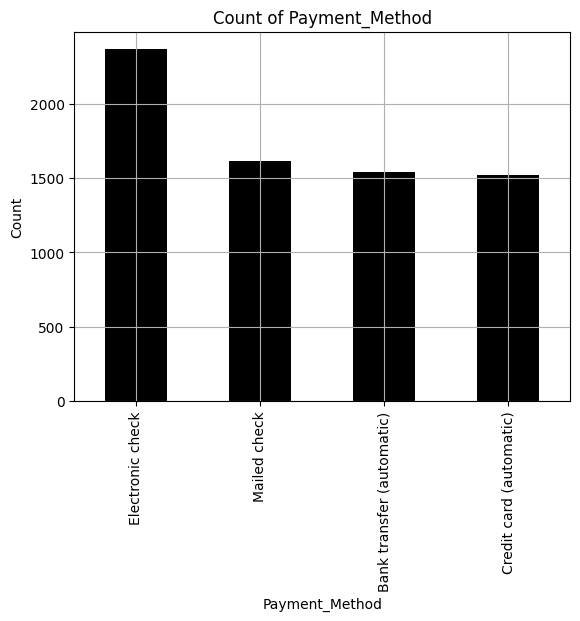

In [2699]:
# Plot the count
df_cat.Payment_Method.value_counts().plot(kind='bar',color='black')
plt.title('Count of Payment_Method')
plt.xlabel('Payment_Method')
plt.ylabel('Count')
plt.grid()
plt.show()

In [2700]:
# Inference
# Maximum payment was done via Electronic Check
# Minimum payment was done using Credit Card (automatic)

In [2701]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Total_Charges', 'Churn'],
      dtype='object')

In [2702]:
# Total_Charges

In [2703]:
# Check the count of each category
df_cat.Total_Charges.value_counts()

,count
Total_Charges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [2704]:
# We need to convert Total_Charges column to number
df_churn_dataset.Total_Charges = pd.to_numeric(
    df_churn_dataset.Total_Charges, errors='coerce'
)

In [2705]:
# Segregate the data based on the data types
df_num = df_churn_dataset.select_dtypes(include='number')
df_cat = df_churn_dataset.select_dtypes(include='object')

In [2706]:
df_num.columns

Index(['Tenure', 'Monthly_Charges', 'Total_Charges'], dtype='object')

In [2707]:
df_num.Total_Charges.min()

18.8

In [2708]:
df_num.Total_Charges.max()

8684.8

In [2709]:
df_num.Total_Charges.mean()

np.float64(2283.3004408418656)

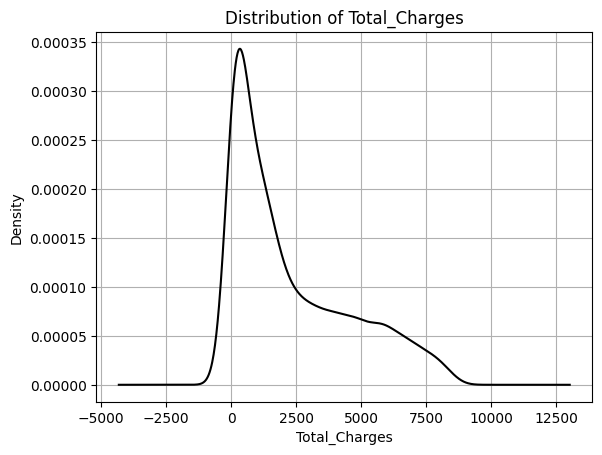

In [2710]:
# Plot the KDE Plot
df_num.Total_Charges.plot(kind='kde',color='black')
plt.grid()
plt.title('Distribution of Total_Charges')
plt.xlabel('Total_Charges')
plt.show()

In [2711]:
# Minimum Total_Charges are: 18.8
# Maximum Total_Charges are: 8684.8
# Average Total_Charges are: 2283.3004408418656

In [2712]:
# Check the columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Churn'],
      dtype='object')

In [2713]:
# Churn

In [2714]:
# Check the number of categories present in this column
df_cat.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869


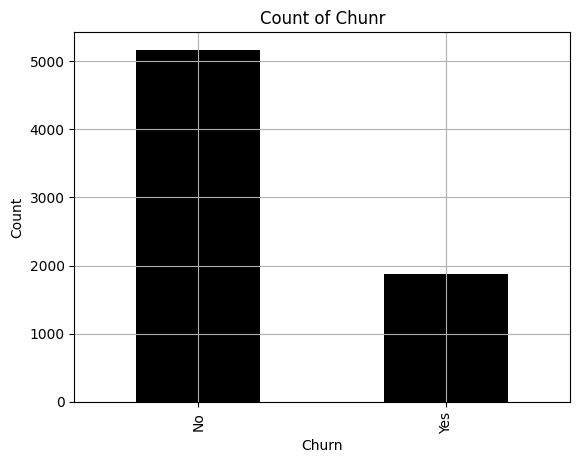

In [2715]:
# Plot the count
df_cat.Churn.value_counts().plot(kind='bar',color='black')
plt.title('Count of Chunr')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.grid()
plt.show()

#### Bivariate Analysis

In [2716]:
# For finding the pairs we have to go for the Correlation matrix
df_num.corr()

,Tenure,Monthly_Charges,Total_Charges
Tenure,1.00000,0.247900,0.825880
Monthly_Charges,0.24790,1.000000,0.651065
Total_Charges,0.82588,0.651065,1.000000


In [2717]:
# Inference
# Due to no correlation lying in our acceptance region so we cannot proceed for NUM-NUM Analysis

In [2718]:
# Bivariate analysis on NUM-CAT

In [2719]:
# Show the categorical columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Churn'],
      dtype='object')

In [2720]:
# Show the numerical columns
df_num.columns

Index(['Tenure', 'Monthly_Charges', 'Total_Charges'], dtype='object')

In [2721]:
# Pair of 1 categorical and 1 numerical
# 'Gender', Tenure
# 'Senir_Citizen', Tenure
# 'Phone_Service', Tenure
# 'Contract', Tenure
# 'Payment_Method', Tenure
# 'Churn', Tenure

# 'Gender', Monthly_Charges
# 'Senir_Citizen', Monthly_Charges
# 'Phone_Service', Monthly_Charges
# 'Contract', Monthly_Charges
# 'Payment_Method', Monthly_Charges
# 'Churn', Monthly_Charges

# 'Gender', Total_Charges
# 'Senir_Citizen', Total_Charges
# 'Phone_Service', Total_Charges
# 'Contract', Total_Charges
# 'Payment_Method', Total_Charges
# 'Churn', Total_Charges

In [2722]:
# 'Gender', Tenure

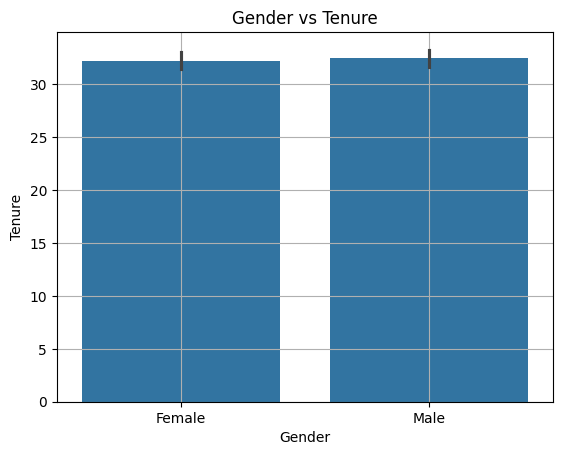

In [2723]:
# Create the bar graph
sns.barplot(x='Gender', y='Tenure', data=df_churn_dataset)
plt.title('Gender vs Tenure')
plt.grid()
plt.show()

In [2724]:
# Inference
# The tenure of male customers is slightly more than the tenure of female customers

In [2725]:
# 'Senior_Citizen', Tenure

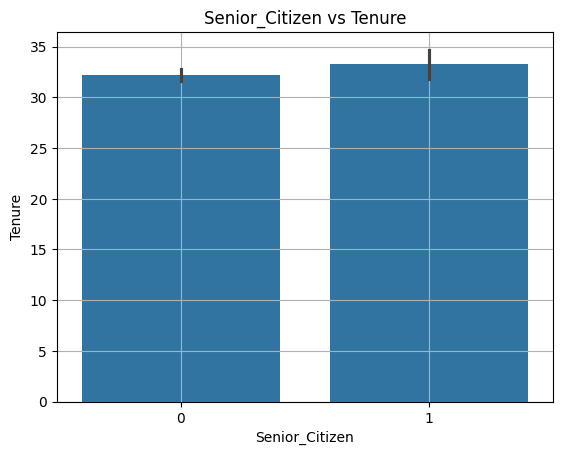

In [2726]:
# Create the bar graph
sns.barplot(x='Senior_Citizen', y='Tenure', data=df_churn_dataset)
plt.title('Senior_Citizen vs Tenure')
plt.grid()
plt.show()

In [2727]:
# Inference
# The tenure of Senior citizens is slightly higher than the tenure of customers who are not senior citizens

In [2728]:
# 'Phone_Service', Tenure

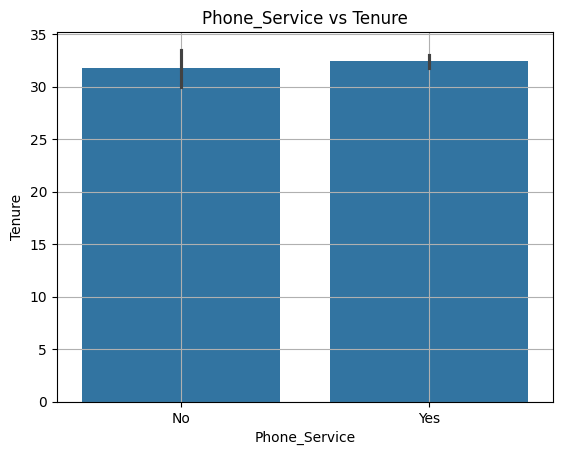

In [2729]:
# Create the bar graph
sns.barplot(x='Phone_Service', y='Tenure', data=df_churn_dataset)
plt.title('Phone_Service vs Tenure')
plt.grid()
plt.show()

In [2730]:
# Inference
# The tenure of customers who have availability of Phone Service Is slightly higher than the customers who do not have phone service

In [2731]:
# 'Contract', Tenure

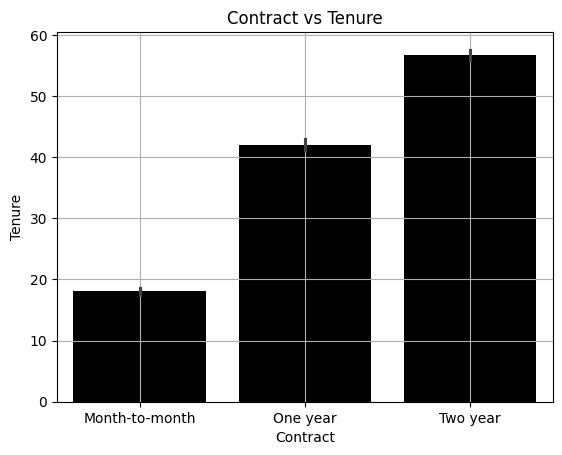

In [2732]:
# Create the bar graph
sns.barplot(x='Contract', y='Tenure', data=df_churn_dataset , color='black')
plt.title('Contract vs Tenure')
plt.grid()
plt.show()

In [2733]:
# Inference
# The customers with two year contract have the highest tenure followed by customer with one year contract and then customers with month-to-month contract

In [2734]:
# 'Payment_Method', Tenure

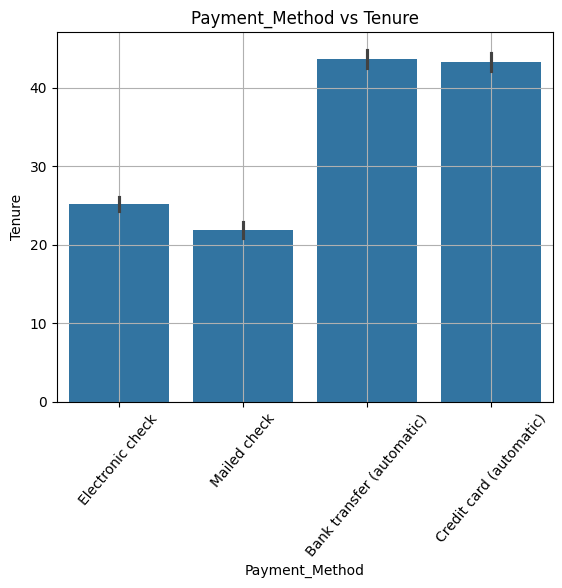

In [2735]:
# Create the bar graph
sns.barplot(x='Payment_Method', y='Tenure', data=df_churn_dataset)
plt.title('Payment_Method vs Tenure')
plt.xticks(rotation=50)
plt.grid()
plt.show()

In [2736]:
# Inference
# The customers who have Payment Method Bank transfer have the highest tenure i.e, nearly 45
# The customers who have Payment Method Mailed check have the least tenure i.e, nearly 22

In [2737]:
# 'Churn', Tenure

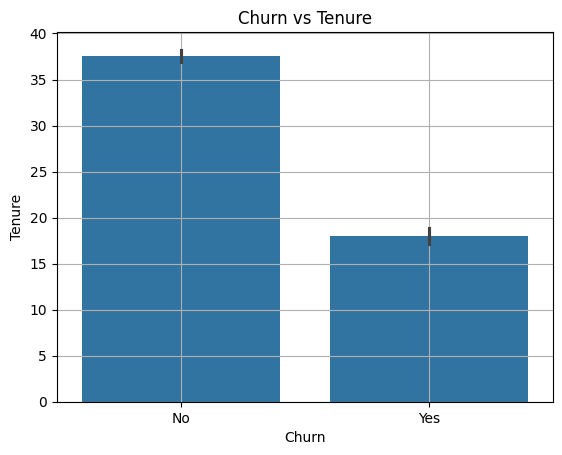

In [2738]:
# Create the bar graph
sns.barplot(x='Churn', y='Tenure', data=df_churn_dataset)
plt.title('Churn vs Tenure')
plt.grid()
plt.show()

In [2739]:
# Inference
# The customers who have high tenure have no churn , but the customers with less tenure have churn

In [2740]:
# 'Gender', Monthly_Charges

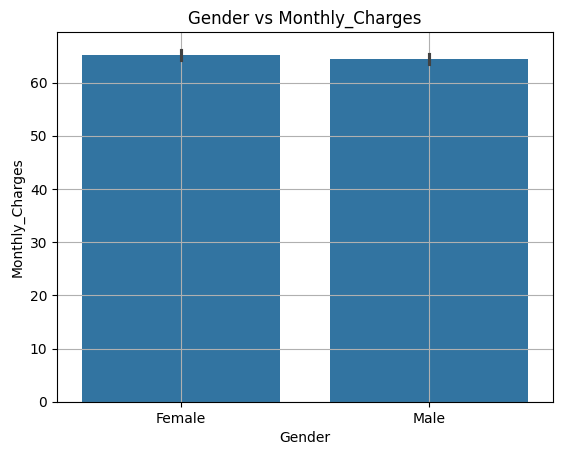

In [2741]:
# Create the bar graph
sns.barplot(x='Gender', y='Monthly_Charges', data=df_churn_dataset)
plt.title('Gender vs Monthly_Charges')
plt.grid()
plt.show()

In [2742]:
# Inference
# The Monthly_Charges of female customers is slightly higher than that of the male customers

In [2743]:
# 'Senir_Citizen', Monthly_Charges

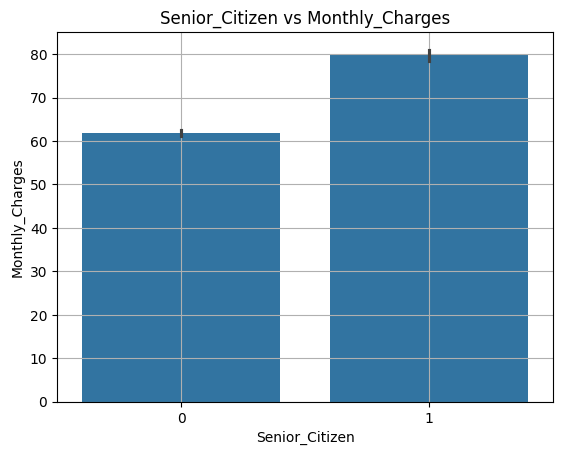

In [2744]:
# Create the bar graph
sns.barplot(x='Senior_Citizen', y='Monthly_Charges', data=df_churn_dataset)
plt.title('Senior_Citizen vs Monthly_Charges')
plt.grid()
plt.show()

In [2745]:
# Inference
# The Monthly_Charges of customers who are Senior_Citizen is significantly higher than the customers who are not Senior_Citizen

In [2746]:
# 'Phone_Service', Monthly_Charges

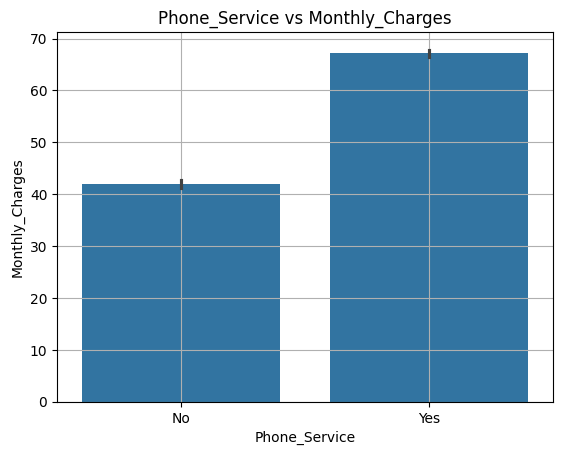

In [2747]:
# Create the bar graph
sns.barplot(x='Phone_Service', y='Monthly_Charges', data=df_churn_dataset)
plt.title('Phone_Service vs Monthly_Charges')
plt.grid()
plt.show()

In [2748]:
# Inference
# The Monthly_Charges of customers who have a phone service is much higher as compared to the Monthly_Charges of customers who do not have a phone service

In [2749]:
# 'Contract', Monthly_Charges

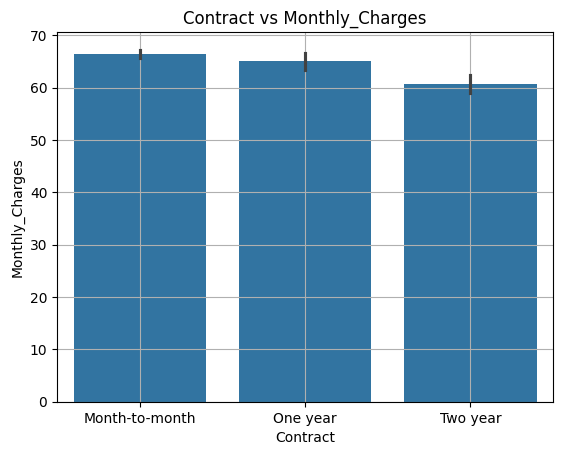

In [2750]:
# Create the bar graph
sns.barplot(x='Contract', y='Monthly_Charges', data=df_churn_dataset)
plt.title('Contract vs Monthly_Charges')
plt.grid()
plt.show()

In [2751]:
# Inference
# The Monthly_Charges of month-to-month contract customers is highest followed by customers with one year contract and then customers with two year contract

In [2752]:
# 'Payment_Method', Monthly_Charges

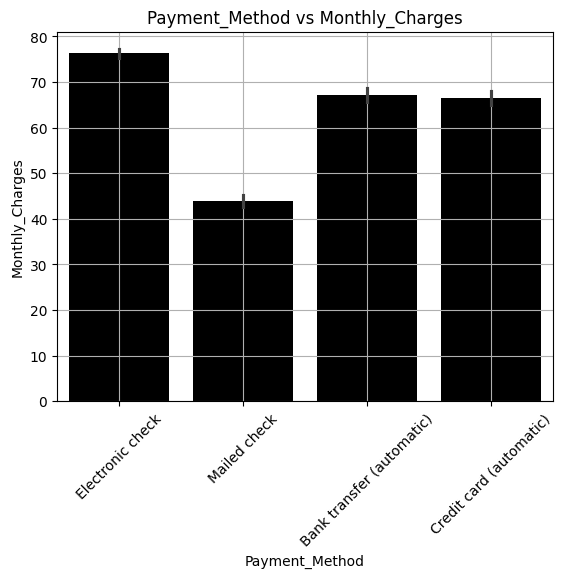

In [2753]:
# Create the bar graph
sns.barplot(x='Payment_Method', y='Monthly_Charges', data=df_churn_dataset , color='black')
plt.title('Payment_Method vs Monthly_Charges')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [2754]:
# Inference
# The maximum Monthly_Charges is for the customers who have their Payment_Method as Electronic check
# The minimum Monthly_Charges is for the customers who have their Payment_Method as Mailed check

In [2755]:
# 'Churn', Monthly_Charges

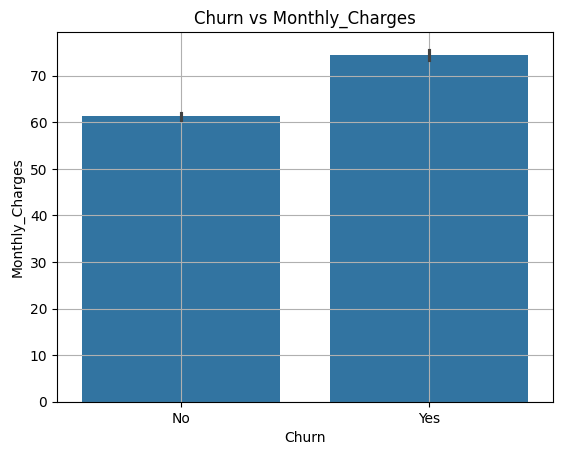

In [2756]:
# Create the bar graph
sns.barplot(x='Churn', y='Monthly_Charges', data=df_churn_dataset)
plt.title('Churn vs Monthly_Charges')
plt.grid()
plt.show()

In [2757]:
# Inference
# The customers with higher Monthly_Charges are more likely to churn

In [2758]:
# 'Gender', Total_Charges

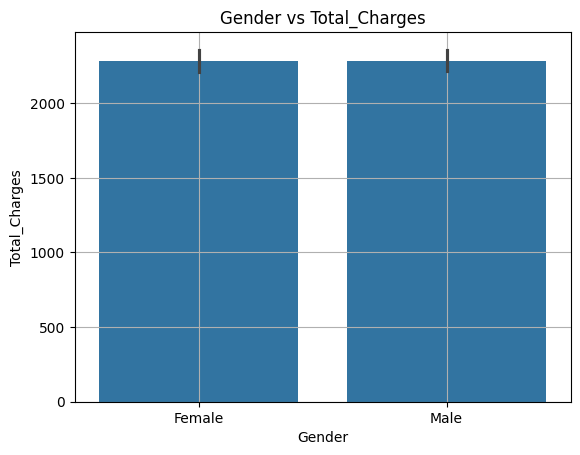

In [2759]:
# Create the bar graph
sns.barplot(x='Gender', y='Total_Charges', data=df_churn_dataset)
plt.title('Gender vs Total_Charges')
plt.grid()
plt.show()

In [2760]:
# Inference
# The Total_Charges of both Female and Male are almost similar i.e, nearky 2500

In [2761]:
# 'Senior_Citizen', Total_Charges

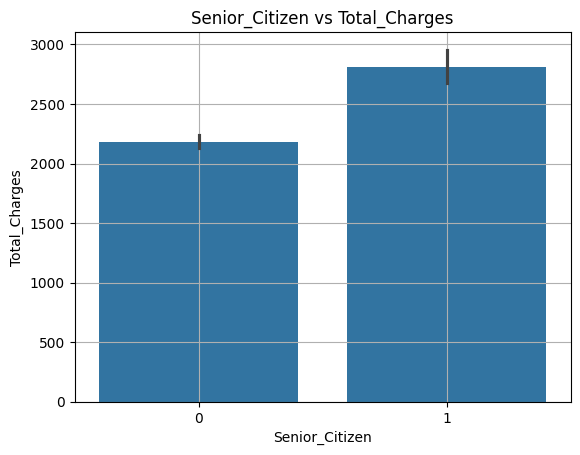

In [2762]:
# Create the bar graph
sns.barplot(x='Senior_Citizen', y='Total_Charges', data=df_churn_dataset)
plt.title('Senior_Citizen vs Total_Charges')
plt.grid()
plt.show()

In [2763]:
# Inference
# The customers who are Senior_Citizen have significantly higher Total_Charges than the customers who are not Senior_Citizen

In [2764]:
# 'Phone_Service', Total_Charges

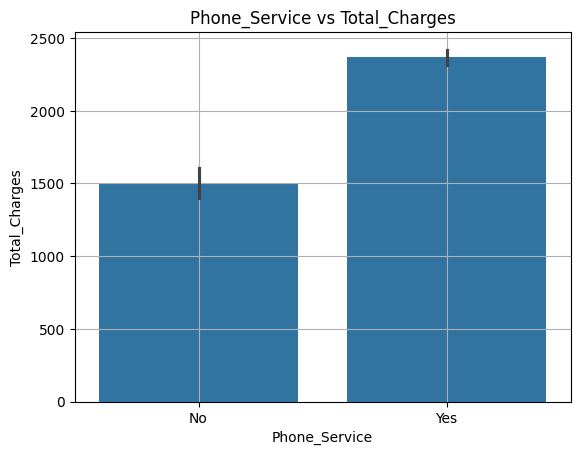

In [2765]:
# Create the bar graph
sns.barplot(x='Phone_Service', y='Total_Charges', data=df_churn_dataset)
plt.title('Phone_Service vs Total_Charges')
plt.grid()
plt.show()

In [2766]:
# The customers who have Phone_Serive have higher Total_Charges

In [2767]:
# 'Contract', Total_Charges

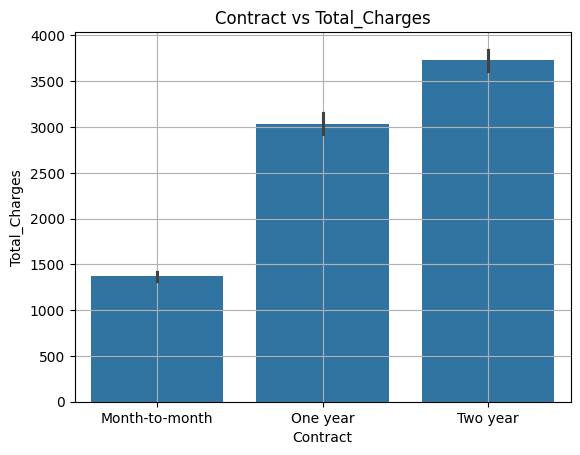

In [2768]:
# Create the bar graph
sns.barplot(x='Contract', y='Total_Charges', data=df_churn_dataset)
plt.title('Contract vs Total_Charges')
plt.grid()
plt.show()

In [2769]:
# Inference
# The customers who have a Two year contract have highest Total_Charges
# The customers with the month-to-month contract have least Total_Charges

In [2770]:
# 'Payment_Method', Total_Charges

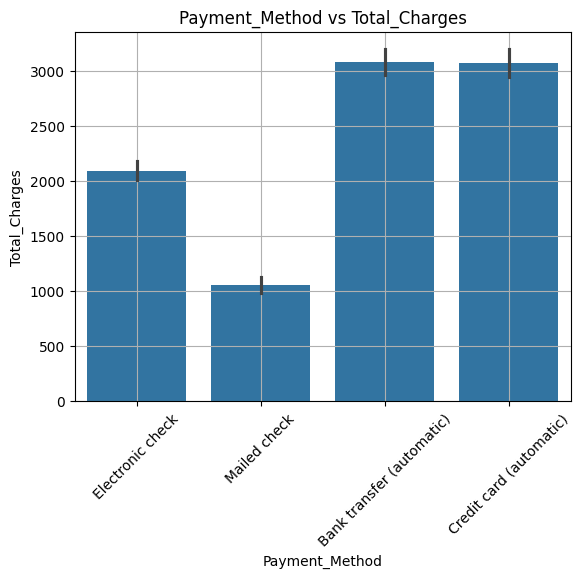

In [2771]:
# Create the bar graph
sns.barplot(x='Payment_Method', y='Total_Charges', data=df_churn_dataset)
plt.title('Payment_Method vs Total_Charges')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [2772]:
# Inference
# The Total_Charges of customers with Payment_Method as Bank Transfer (automatic) is highest which is almost similar to the customers with Credit card (automatic) Payment_Method
# The least Total_Charges ia of customers who have their Payment_Method as Mailed check

In [2773]:
# 'Churn', Total_Charges

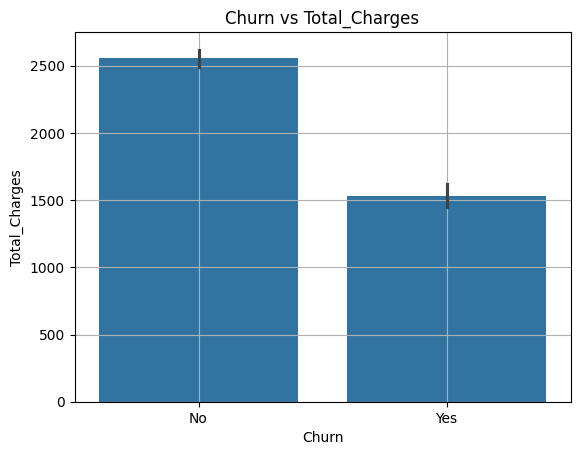

In [2774]:
# Create the bar graph
sns.barplot(x='Churn', y='Total_Charges', data=df_churn_dataset)
plt.title('Churn vs Total_Charges')
plt.grid()
plt.show()

In [2775]:
# Inference
# The customers who have less Total_Charges are more likely to Churn

#### Multivariate Analysis

In [2776]:
# Just because we haven't got any kind of pairs in correlation matrix we can't proceed for the NUM-NUM-CAT analysis

In [2777]:
# CAT-CAT-NUM Analysis

In [2778]:
# Check the cat columns
df_cat.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Churn'],
      dtype='object')

In [2779]:
# Check the numerical columns
df_num.columns

Index(['Tenure', 'Monthly_Charges', 'Total_Charges'], dtype='object')

In [2780]:
# Gender , Churn , Tenure
# Phone_Service , Churn , Tenure
# Internet_Service , Churn , Tenure
# Contract , Churn , Tenure
# Payment_Method , Churn , Tenure

# Gender , Payment_Method , Tenure
# Phone_Service , Payment_Method , Tenure
# Internet_Service , Payment_Method , Tenure
# Contract , Payment_Method , Tenure

# Gender , Contract , Tenure
# Phone_Service , Contract , Tenure
# Internet_Service , Contract , Tenure

In [2781]:
# Gender , Churn , Monthly_Charges
# Phone_Service , Churn , Monthly_Charges
# Internet_Service , Churn , Monthly_Charges
# Contract , Churn , Monthly_Charges
# Payment_Method , Churn , Monthly_Charges

# Gender , Payment_Method , Monthly_Charges
# Phone_Service , Payment_Method , Monthly_Charges
# Internet_Service , Payment_Method , Monthly_Charges
# Contract , Payment_Method , Monthly_Charges

# Gender , Contract , Monthly_Charges
# Phone_Service , Contract , Monthly_Charges
# Internet_Service , Contract , Monthly_Charges

In [2782]:
# Gender , Churn , Total_Charges
# Phone_Service , Churn , Total_Charges
# Internet_Service , Churn , Total_Charges
# Contract , Churn , Total_Charges
# Payment_Method , Churn , Total_Charges

# Gender , Payment_Method , Total_Charges
# Phone_Service , Payment_Method , Total_Charges
# Internet_Service , Payment_Method , Total_Charges
# Contract , Payment_Method , Total_Charges

# Gender , Contract , Total_Charges
# Phone_Service , Contract , Total_Charges
# Internet_Service , Contract , Total_Charges

In [2783]:
# Gender , Churn , Tenure

In [2784]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='mean')

Churn,No,Yes
Gender,,
Female,37.858768,17.004260
Male,37.289524,18.963441


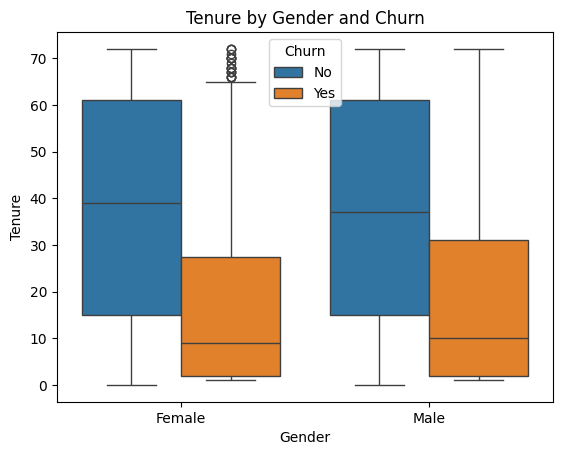

In [2785]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Gender',
    y='Tenure',
    hue='Churn'
)

plt.title("Tenure by Gender and Churn")
plt.show()

In [2786]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='min')

Churn,No,Yes
Gender,,
Female,0,1
Male,0,1


In [2787]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='max')

Churn,No,Yes
Gender,,
Female,72,72
Male,72,72


In [2788]:
# Phone_Service , Churn , Tenure

In [2789]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='mean')

Churn,No,Yes
Phone_Service,,
No,37.017578,15.835294
Yes,37.630631,18.193643


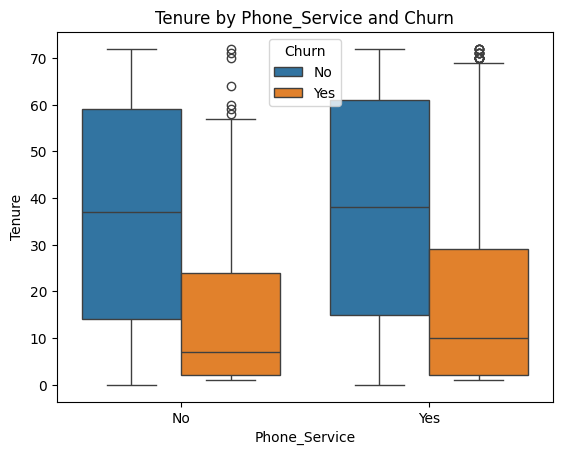

In [2790]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Phone_Service',
    y='Tenure',
    hue='Churn'
)

plt.title("Tenure by Phone_Service and Churn")
plt.show()

In [2791]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='min')

Churn,No,Yes
Phone_Service,,
No,0,1
Yes,0,1


In [2792]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='max')

Churn,No,Yes
Phone_Service,,
No,72,72
Yes,72,72


In [2793]:
# Internet_Service , Churn , Tenure

In [2794]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='mean')

Churn,No,Yes
Internet_Service,,
DSL,37.198777,14.111111
Fiber optic,42.089494,20.196608
No,32.331210,8.238938


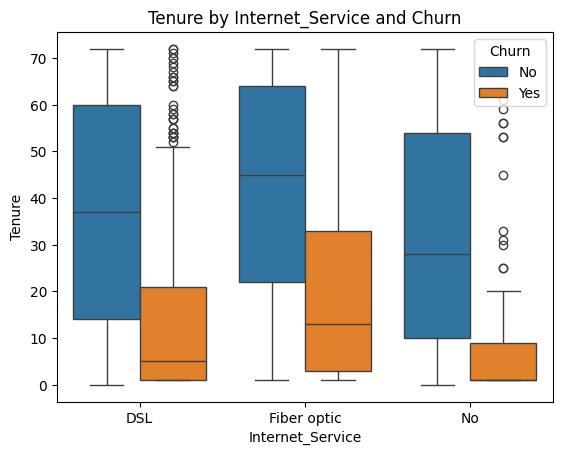

In [2795]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Internet_Service',
    y='Tenure',
    hue='Churn'
)

plt.title("Tenure by Internet_Service and Churn")
plt.show()

In [2796]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='min')

Churn,No,Yes
Internet_Service,,
DSL,0,1
Fiber optic,1,1
No,0,1


In [2797]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='max')

Churn,No,Yes
Internet_Service,,
DSL,72,72
Fiber optic,72,72
No,72,61


In [2798]:
# Contract , Churn , Tenure

In [2799]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='mean')

Churn,No,Yes
Contract,,
Month-to-month,21.033333,14.016918
One year,41.674063,44.963855
Two year,56.602914,61.270833


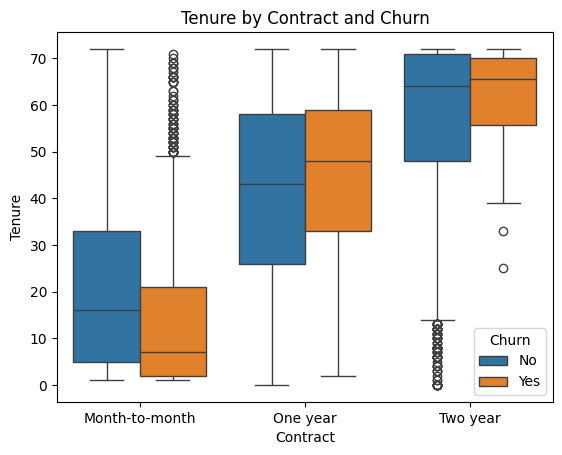

In [2800]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Contract',
    y='Tenure',
    hue='Churn'
)

plt.title("Tenure by Contract and Churn")
plt.show()

In [2801]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='min')

Churn,No,Yes
Contract,,
Month-to-month,1,1
One year,0,2
Two year,0,25


In [2802]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='max')

Churn,No,Yes
Contract,,
Month-to-month,72,71
One year,72,72
Two year,72,72


In [2803]:
# Payment_Method , Churn , Tenure

In [2804]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Payment_Method , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='mean')

Churn,No,Yes
Payment_Method,,
Bank transfer (automatic),47.140747,26.290698
Credit card (automatic),46.101550,27.521552
Electronic check,32.136012,16.763772
Mailed check,25.083589,8.055195


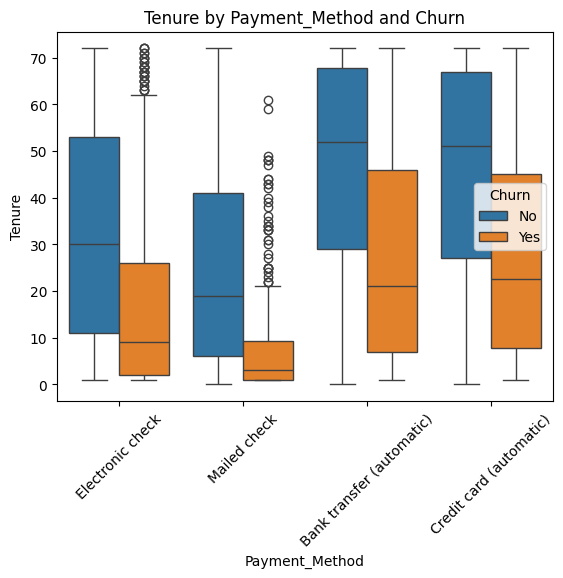

In [2805]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Payment_Method',
    y='Tenure',
    hue='Churn'
)
plt.xticks(rotation=45)
plt.title("Tenure by Payment_Method and Churn")
plt.show()

In [2806]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Payment_Method , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='min')

Churn,No,Yes
Payment_Method,,
Bank transfer (automatic),0,1
Credit card (automatic),0,1
Electronic check,1,1
Mailed check,0,1


In [2807]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Payment_Method , columns=df_churn_dataset.Churn , values=df_churn_dataset.Tenure , aggfunc='max')

Churn,No,Yes
Payment_Method,,
Bank transfer (automatic),72,72
Credit card (automatic),72,72
Electronic check,72,72
Mailed check,72,61


In [2808]:
# Gender , Payment_Method , Tenure

In [2809]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='mean')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Gender,,,,
Female,43.336294,43.405585,24.373504,22.059126
Male,43.990741,43.136364,25.958996,21.616307


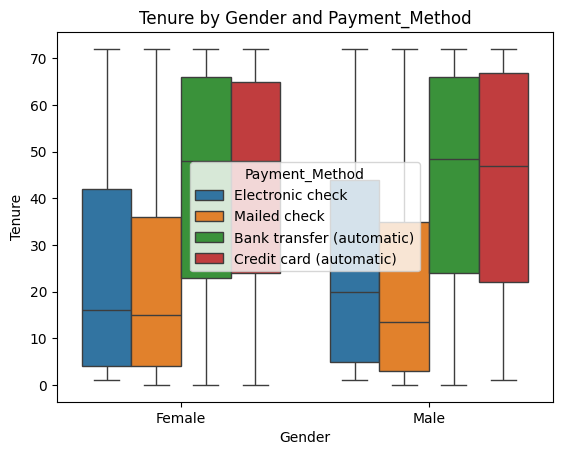

In [2810]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Gender',
    y='Tenure',
    hue='Payment_Method'
)

plt.title("Tenure by Gender and Payment_Method")
plt.show()

In [2811]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='min')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Gender,,,,
Female,0,0,1,0
Male,0,1,1,0


In [2812]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='max')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Gender,,,,
Female,72,72,72,72
Male,72,72,72,72


In [2813]:
# Phone_Service , Payment_Method , Tenure

In [2814]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='mean')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Phone_Service,,,,
No,46.671329,39.870130,25.207965,19.710692
Yes,43.349036,43.652047,25.171108,22.061941


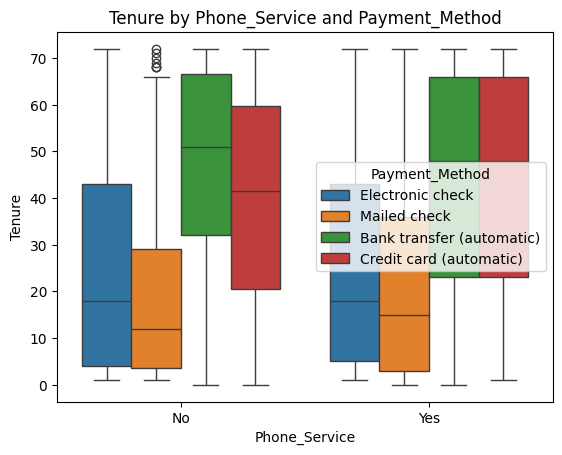

In [2815]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Phone_Service',
    y='Tenure',
    hue='Payment_Method'
)

plt.title("Tenure by Phone_Service and Payment_Method")
plt.show()

In [2816]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='min')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Phone_Service,,,,
No,0,0,1,1
Yes,0,1,1,0


In [2817]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='max')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Phone_Service,,,,
No,72,72,72,72
Yes,72,72,72,72


In [2818]:
# Internet_Service , Payment_Method , Tenure

In [2819]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='mean')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Internet_Service,,,,
DSL,44.217314,43.271044,23.535494,21.990212
Fiber optic,43.761610,44.854271,25.865831,21.744186
No,42.496988,40.407855,24.844262,21.727395


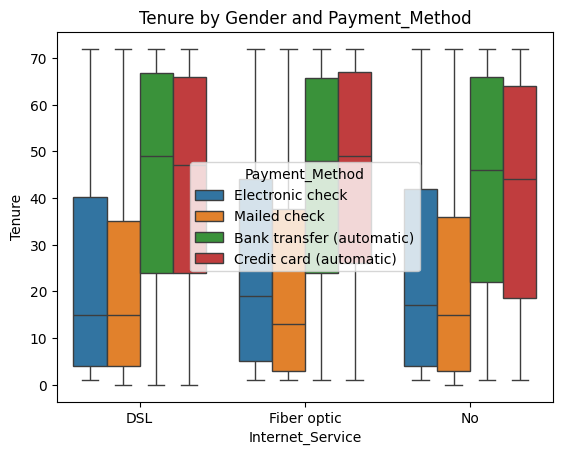

In [2820]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Internet_Service',
    y='Tenure',
    hue='Payment_Method'
)

plt.title("Tenure by Gender and Payment_Method")
plt.show()

In [2821]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='min')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Internet_Service,,,,
DSL,0,0,1,0
Fiber optic,1,1,1,1
No,1,1,1,0


In [2822]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='max')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Internet_Service,,,,
DSL,72,72,72,72
Fiber optic,72,72,72,72
No,72,72,72,72


In [2823]:
# Contract , Payment_Method , Tenure

In [2824]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='mean')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,24.904924,23.955801,17.971351,10.042553
One year,46.017903,45.477387,46.178674,29.124629
Two year,61.602837,59.807229,61.113095,42.950262


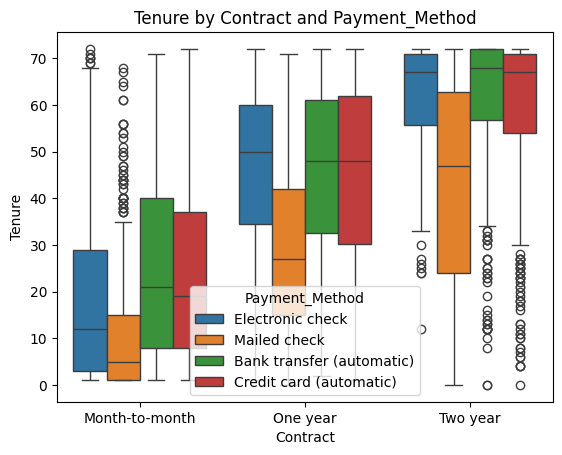

In [2825]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Contract',
    y='Tenure',
    hue='Payment_Method'
)

plt.title("Tenure by Contract and Payment_Method")
plt.show()

In [2826]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='min')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,1,1,1,1
One year,2,1,1,0
Two year,0,0,12,0


In [2827]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Contract , columns=df_churn_dataset.Payment_Method , values=df_churn_dataset.Tenure , aggfunc='max')

Payment_Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,71,72,72,68
One year,72,72,72,71
Two year,72,72,72,72


In [2828]:
# Gender , Contract , Tenure

In [2829]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='mean')

Contract,Month-to-month,One year,Two year
Gender,,,
Female,17.974026,42.445682,56.086391
Male,18.098462,41.663576,57.380000


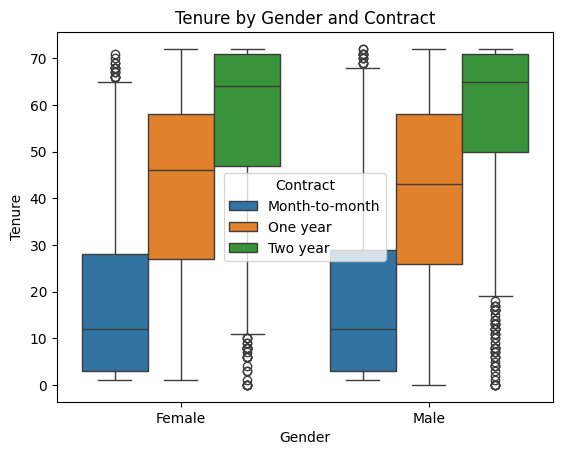

In [2830]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Gender',
    y='Tenure',
    hue='Contract'
)

plt.title("Tenure by Gender and Contract")
plt.show()

In [2831]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='min')

Contract,Month-to-month,One year,Two year
Gender,,,
Female,1,1,0
Male,1,0,0


In [2832]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Gender , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='max')

Contract,Month-to-month,One year,Two year
Gender,,,
Female,71,72,72
Male,72,72,72


In [2833]:
# Phone_Service , Contract , Tenure

In [2834]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='mean')

Contract,Month-to-month,One year,Two year
Phone_Service,,,
No,18.654255,39.675862,55.142857
Yes,17.970277,42.303464,56.902216


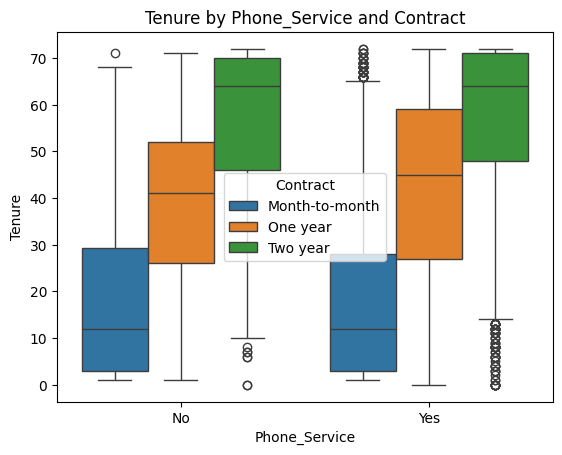

In [2835]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Phone_Service',
    y='Tenure',
    hue='Contract'
)

plt.title("Tenure by Phone_Service and Contract")
plt.show()

In [2836]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='min')

Contract,Month-to-month,One year,Two year
Phone_Service,,,
No,1,1,0
Yes,1,0,0


In [2837]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Phone_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='max')

Contract,Month-to-month,One year,Two year
Phone_Service,,,
No,71,71,72
Yes,72,72,72


In [2838]:
# Internet_Service , Contract , Tenure

In [2839]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='mean')

Contract,Month-to-month,One year,Two year
Internet_Service,,,
DSL,15.732625,40.487719,59.143312
Fiber optic,21.554981,52.098330,65.184149
No,9.125954,29.596154,48.683386


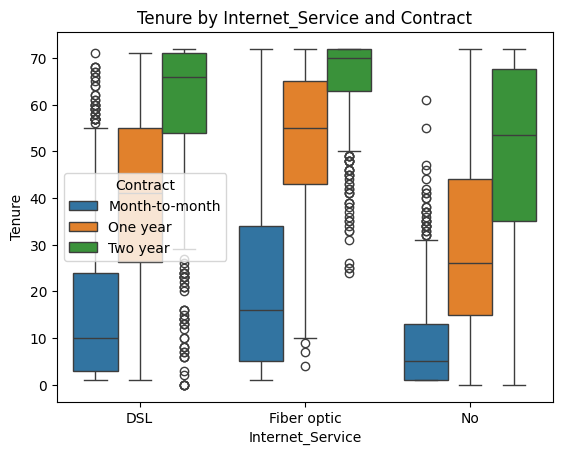

In [2840]:
# Plot a Box Plot
sns.boxplot(
    data=df_churn_dataset,
    x='Internet_Service',
    y='Tenure',
    hue='Contract'
)

plt.title("Tenure by Internet_Service and Contract")
plt.show()

In [2841]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='min')

Contract,Month-to-month,One year,Two year
Internet_Service,,,
DSL,1,1,0
Fiber optic,1,4,24
No,1,0,0


In [2842]:
# Create the Crosstab
pd.crosstab(index=df_churn_dataset.Internet_Service , columns=df_churn_dataset.Contract , values=df_churn_dataset.Tenure , aggfunc='max')

Contract,Month-to-month,One year,Two year
Internet_Service,,,
DSL,71,71,72
Fiber optic,72,72,72
No,61,72,72


## Prepare the data for ML

In [2843]:
# Check the irrelevant columns
df_churn_dataset.columns

Index(['Customer_ID', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Tenure', 'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn'],
      dtype='object')

In [2844]:
# Drop the unnecessary columns
df_churn_dataset.drop('Customer_ID', axis=1, inplace= True)
df_churn_dataset.drop('Partner', axis=1, inplace= True)
df_churn_dataset.drop('Dependents', axis=1, inplace= True)
df_churn_dataset.drop('Multiple_Lines', axis=1, inplace= True)
df_churn_dataset.drop('Online_Security', axis=1, inplace= True)
df_churn_dataset.drop('Online_Backup', axis=1, inplace= True)
df_churn_dataset.drop('Device_Protection', axis=1, inplace= True)
df_churn_dataset.drop('Tech_Support', axis=1, inplace= True)
df_churn_dataset.drop('Streaming_TV', axis=1, inplace= True)
df_churn_dataset.drop('Streaming_Movies', axis=1, inplace= True)
df_churn_dataset.drop('Paperless_Billing', axis=1, inplace= True)

In [2845]:
# Check the columns
df_churn_dataset.columns

Index(['Gender', 'Senior_Citizen', 'Tenure', 'Phone_Service',
       'Internet_Service', 'Contract', 'Payment_Method', 'Monthly_Charges',
       'Total_Charges', 'Churn'],
      dtype='object')

In [2846]:
# Segregate the target variable
target = df_churn_dataset['Churn']
df_churn_dataset = df_churn_dataset.drop('Churn', axis=1)

In [2847]:
# Segregate the data based on data types
# To scale the numerical columns
df_cat=df_churn_dataset.select_dtypes(include='object')
df_num=df_churn_dataset.select_dtypes(include='number')

In [2848]:
# Check the dataframes
df_cat.head()

,Gender,Senior_Citizen,Phone_Service,Internet_Service,Contract,Payment_Method
0,Female,0,No,DSL,Month-to-month,Electronic check
1,Male,0,Yes,DSL,One year,Mailed check
2,Male,0,Yes,DSL,Month-to-month,Mailed check
3,Male,0,No,DSL,One year,Bank transfer (automatic)
4,Female,0,Yes,Fiber optic,Month-to-month,Electronic check


In [2849]:
# Check for num
df_num.head()

,Tenure,Monthly_Charges,Total_Charges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [2850]:
# Encode the categorical variables

In [2851]:
# Create the encoded dataframe
encoded=pd.get_dummies(df_cat)
encoded.head()

,Gender_Female,Gender_Male,Senior_Citizen_0,Senior_Citizen_1,Phone_Service_No,Phone_Service_Yes,Internet_Service_DSL,Internet_Service_Fiber optic,Internet_Service_No,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment_Method_Bank transfer (automatic),Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check
0,True,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False
1,False,True,True,False,False,True,True,False,False,False,True,False,False,False,False,True
2,False,True,True,False,False,True,True,False,False,True,False,False,False,False,False,True
3,False,True,True,False,True,False,True,False,False,False,True,False,True,False,False,False
4,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,False


In [2852]:
# Scale the numerical variable

In [2853]:
# Prepare the library
from sklearn.preprocessing import StandardScaler

# Initiate teh Standard Scaler
ss= StandardScaler()

# Transform the numeric data
scalled = ss.fit_transform(df_num)

In [2854]:
# Check the scalled data
scalled

array([[-1.27744458, -1.16032292, -0.99419409],
       [ 0.06632742, -0.25962894, -0.17373982],
       [-1.23672422, -0.36266036, -0.95964911],
       ...,
       [-0.87024095, -1.1686319 , -0.85451414],
       [-1.15528349,  0.32033821, -0.87209546],
       [ 1.36937906,  1.35896134,  2.01234407]])

In [2855]:
# Conver the array into the dataframe
df_scalled=pd.DataFrame(scalled, columns=df_num.columns)
df_scalled.head()

,Tenure,Monthly_Charges,Total_Charges
0,-1.277445,-1.160323,-0.994194
1,0.066327,-0.259629,-0.173740
2,-1.236724,-0.362660,-0.959649
3,0.514251,-0.746535,-0.195248
4,-1.236724,0.197365,-0.940457


In [2856]:
# So now connect the encoded dataframe and scalled dataframe
x=pd.concat([df_scalled,encoded], axis=1)
x.head()

,Tenure,Monthly_Charges,Total_Charges,Gender_Female,Gender_Male,Senior_Citizen_0,Senior_Citizen_1,Phone_Service_No,Phone_Service_Yes,Internet_Service_DSL,Internet_Service_Fiber optic,Internet_Service_No,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment_Method_Bank transfer (automatic),Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check
0,-1.277445,-1.160323,-0.994194,True,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False
1,0.066327,-0.259629,-0.173740,False,True,True,False,False,True,True,False,False,False,True,False,False,False,False,True
2,-1.236724,-0.362660,-0.959649,False,True,True,False,False,True,True,False,False,True,False,False,False,False,False,True
3,0.514251,-0.746535,-0.195248,False,True,True,False,True,False,True,False,False,False,True,False,True,False,False,False
4,-1.236724,0.197365,-0.940457,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,False


## Classification

In [2857]:
# Import the required libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
x_train,x_test,y_train,y_test = train_test_split(x,target,train_size=0.8,random_state=20)

x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_train.mean())

In [2858]:
# Check the training data and testing data
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [2859]:
# Logistic Regression

In [2860]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr = LogisticRegression(random_state=42)

# Train the model
lr.fit(x_train, y_train)

# Predict on the test data
lr_prediction = lr.predict(x_test)

# Calculate accuracy
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8168914123491838


In [2861]:
# Decision Tree

In [2862]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(x_train, y_train)

# Predict on the test data
dt_prediction = dt.predict(x_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.730305180979418


In [2863]:
# Random Forest

In [2864]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(x_train, y_train)

# Predict on the test data
rf_prediction = rf.predict(x_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7927608232789212


In [2865]:
# KNN

In [2866]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict on the test data
knn_prediction = knn.predict(x_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_prediction)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7863733144073811


In [2867]:
# Naive Bayes

In [2868]:
# Import Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create the Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(x_train, y_train)

# Predict on the test data
nb_prediction = nb.predict(x_test)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_prediction)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.730305180979418


In [2869]:
# SVM

In [2870]:
# Import Support Vector Machine
from sklearn.svm import SVC

# Create the SVM model
svm = SVC(random_state=42)

# Train the model
svm.fit(x_train, y_train)

# Predict on the test data
svm_prediction = svm.predict(x_test)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, svm_prediction)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8119233498935415


## Model Comparison

In [2871]:
# Create a dictionary of model accuracies

model_accuracy = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "Naive Bayes": nb_accuracy,
    "Support Vector Machine": svm_accuracy
}

In [2872]:
# Convert dictionary into DataFrame

accuracy_df = pd.DataFrame(
    model_accuracy.items(),
    columns=["Algorithm", "Accuracy"]
)


In [2873]:
# Sort by Accuracy

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

In [2874]:
# Display the table

accuracy_df

,Algorithm,Accuracy
0,Logistic Regression,0.816891
5,Support Vector Machine,0.811923
2,Random Forest,0.792761
3,KNN,0.786373
1,Decision Tree,0.730305
4,Naive Bayes,0.730305


In [2875]:
# Display the best model

best_model = accuracy_df.iloc[0]

print("Best Model :", best_model["Algorithm"])
print("Accuracy :", round(best_model["Accuracy"] * 100, 2), "%")

Best Model : Logistic Regression
Accuracy : 81.69 %


## Confusion Matrix and Classification Report

In [2876]:
# Display Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[951 112]
 [146 200]]


In [2877]:
# Display Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.89      0.88      1063
         Yes       0.64      0.58      0.61       346

    accuracy                           0.82      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.81      0.82      0.81      1409



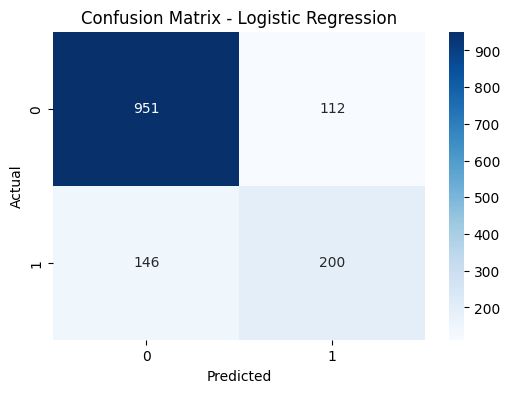

In [2878]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Unsupervised Machine Learning

In [2879]:
# Import Libraries

from sklearn.cluster import KMeans

In [2880]:
# Select Features for Clustering

X_cluster = df_churn_dataset[['Tenure', 'Monthly_Charges']]

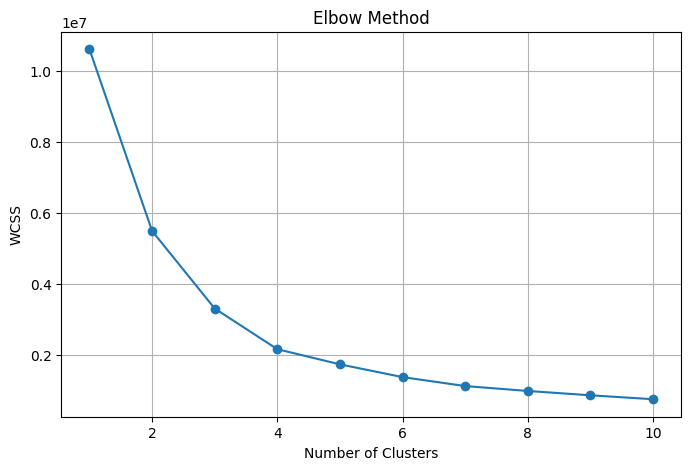

In [2881]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

In [2882]:
# Inference
# As per the elbow method we can say that the appropriate number of clusters are 4

In [2883]:
# Train K-Means Model

kmeans = KMeans(n_clusters=4, random_state=42)

df_churn_dataset['Cluster'] = kmeans.fit_predict(X_cluster)

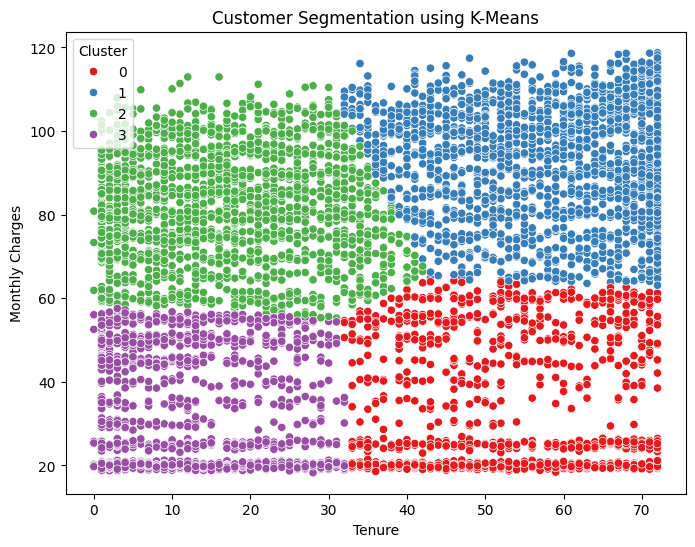

In [2884]:
# Visualize Clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_churn_dataset,
    x='Tenure',
    y='Monthly_Charges',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

In [2885]:
# Cluster Centers

print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[54.22434783 34.00126087]
 [58.59141982 93.29752298]
 [14.8189263  80.95154686]
 [10.55728267 32.47386298]]


## Prediction Using Logistic Regression

In [2886]:
# Take one customer from the test dataset

sample_customer = x_test.iloc[[0]]

# Predict the churn

prediction = lr.predict(sample_customer)

In [2887]:
# Display the prediction

if prediction[0] == 1:
    print("Prediction: Customer will Churn")
else:
    print("Prediction: Customer will Not Churn")

Prediction: Customer will Not Churn


In [2888]:
# Actual Churn Value

actual = y_test.iloc[0]

print("Actual Value :", actual)

if actual == 1:
    print("Actual Status : Customer Churned")
else:
    print("Actual Status : Customer Did Not Churn")

Actual Value : No
Actual Status : Customer Did Not Churn
